some try error

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 讀取 CSV 資料
file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250428\H10M22S46\q4_TomoGateErrorTest_20250428102913_TomoGateError.csv"
df = pd.read_csv(file_path)

# 將比例轉換為期望值範圍 [-1, 1]
def expectation_from_prob(p):
    return 2 * p - 1

X_exp = expectation_from_prob(df["X Data"].values)
Y_exp = expectation_from_prob(df["Y Data"].values)
Z_exp = expectation_from_prob(df["Z Data"].values)

# Pauli matrices
I = np.eye(2)
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

# 將期望值轉換為 density matrix
def build_density_matrix(x, y, z):
    return 0.5 * (I + x * sigma_x + y * sigma_y + z * sigma_z)

density_matrices = [build_density_matrix(x, y, z) for x, y, z in zip(X_exp, Y_exp, Z_exp)]



# 儲存 h 向量
hx_list, hy_list, hz_list = [], [], []

for n in range(len(density_matrices) - 1):
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]

    # 旋轉 rho_n
    rotated = sigma_x @ rho_n @ sigma_x
    delta_rho = rho_np1 - rotated

    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 建立係數矩陣 M[k, j] = Tr(-i [σ_j, ρ_n] ⋅ σ_k)
    M = np.zeros((3, 3))
    for k, sigma_k in enumerate(paulis):
        for j, sigma_j in enumerate(paulis):
            comm = sigma_j @ rho_n - rho_n @ sigma_j
            M[k, j] = np.trace(-1j * comm @ sigma_k).real  # 這裡順序正確！

    # 解線性方程 M h = v
    try:
        h_vector, *_ = np.linalg.lstsq(M, v, rcond=None)
    except Exception:
        h_vector = np.array([np.nan, np.nan, np.nan])
    
    # lambda_reg = 1e-3  # 正則化強度，可微調
    # try:
    #     h_vector = np.linalg.solve(M.T @ M + lambda_reg * np.eye(3), M.T @ v)
    # except Exception:
    #     h_vector = np.array([np.nan, np.nan, np.nan])

    # U, S, Vh = np.linalg.svd(M)
    # S_inv = np.array([1/s if s > 1e-6 else 0 for s in S])
    # M_pinv = Vh.T @ np.diag(S_inv) @ U.T
    # h_vector = M_pinv @ v


    hx_list.append(h_vector[0])
    hy_list.append(h_vector[1])
    hz_list.append(h_vector[2])

# 繪圖
# fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
# x_axis = df["Gate Num"].values[1:]

# ax[0].bar(x_axis, hx_list, color='r')
# ax[0].set_ylabel("h_x")
# ax[0].set_title("Hamiltonian Distribution")

# ax[1].bar(x_axis, hy_list, color='g')
# ax[1].set_ylabel("h_y")

# ax[2].bar(x_axis, hz_list, color='b')
# ax[2].set_ylabel("h_z")
# ax[2].set_xlabel("Gate Number")

# plt.tight_layout()
# plt.show()


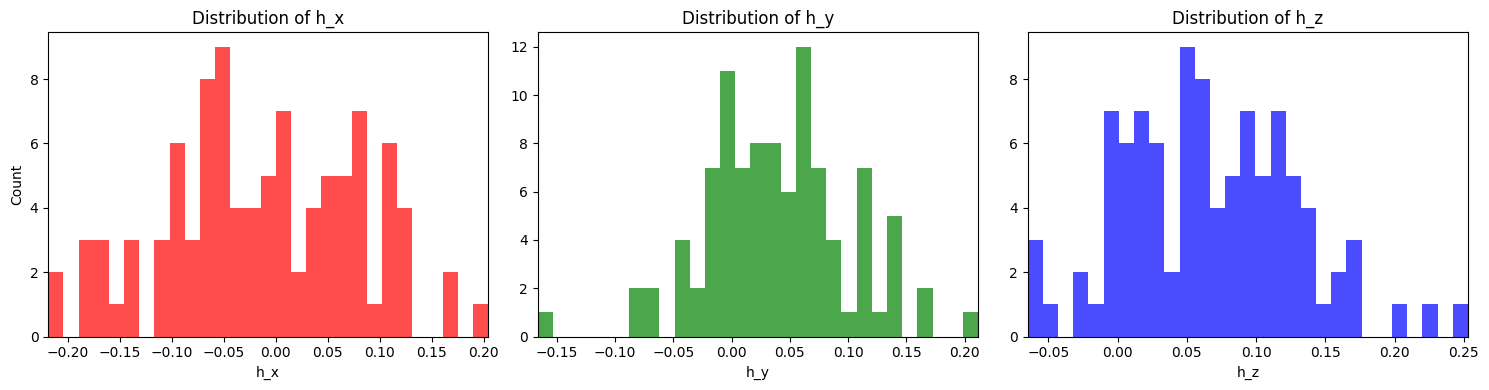

In [159]:

# 改為畫出直方圖（histogram）
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# 移除 nan 值
hx_clean = [h for h in hx_list if not np.isnan(h)]
hy_clean = [h for h in hy_list if not np.isnan(h)]
hz_clean = [h for h in hz_list if not np.isnan(h)]

# 自動計算範圍
hx_min, hx_max = min(hx_clean), max(hx_clean)
hy_min, hy_max = min(hy_clean), max(hy_clean)
hz_min, hz_max = min(hz_clean), max(hz_clean)

# 依據範圍自動切 bins（你也可以設固定數量，如 bins=50）
hx_bins = np.linspace(hx_min, hx_max, 30)
hy_bins = np.linspace(hy_min, hy_max, 30)
hz_bins = np.linspace(hz_min, hz_max, 30)

# 畫 histogram
ax[0].hist(hx_clean, bins=hx_bins, color='r', alpha=0.7)
ax[0].set_xlabel("h_x")
ax[0].set_ylabel("Count")
ax[0].set_title("Distribution of h_x")
ax[0].set_xlim(hx_min, hx_max)

ax[1].hist(hy_clean, bins=hy_bins, color='g', alpha=0.7)
ax[1].set_xlabel("h_y")
ax[1].set_title("Distribution of h_y")
ax[1].set_xlim(hy_min, hy_max)

ax[2].hist(hz_clean, bins=hz_bins, color='b', alpha=0.7)
ax[2].set_xlabel("h_z")
ax[2].set_title("Distribution of h_z")
ax[2].set_xlim(hz_min, hz_max)

plt.tight_layout()
plt.show()


In [160]:
h = hx_list[1]*sigma_x + hy_list[1]*sigma_y + hz_list[1]*sigma_z 
print(h)
delta = -1j* (h @ density_matrices[1] - density_matrices[1] @ h)
print(delta)
delta2 = density_matrices[2] - sigma_x @ density_matrices[1] @ sigma_x
print(delta2)



[[ 0.00576289+0.j         -0.09015668+0.03593413j]
 [-0.09015668-0.03593413j -0.00576289+0.j        ]]
[[ 0.00652786-0.j          0.01925594+0.04726515j]
 [ 0.01925594-0.04726515j -0.00652786+0.j        ]]
[[-0.027+0.j     0.019+0.052j]
 [ 0.019-0.052j  0.027+0.j   ]]


In [161]:
import numpy as np
import matplotlib.pyplot as plt

# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

# 存放結果
hx_list, hy_list, hz_list = [], [], []
coh_error_list, decoh_error_list, total_error_list = [], [], []

# 主迴圈：對每個相鄰的 rho_n, rho_{n+1} 做分析
for n in range(len(density_matrices) - 1):
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]

    # 理想演化
    rotated = sigma_x @ rho_n @ sigma_x
    delta_rho = rho_np1 - rotated

    # 計算 RHS: v_k = Tr(delta_rho ⋅ sigma_k)
    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 計算 M[k, j] = Tr(-i [sigma_j, rho_n] ⋅ sigma_k)
    M = np.zeros((3, 3))
    for k, sigma_k in enumerate(paulis):
        for j, sigma_j in enumerate(paulis):
            comm = sigma_j @ rho_n - rho_n @ sigma_j
            M[k, j] = np.trace(-1j * comm @ sigma_k).real

    # 解 h_vector: M h = v
    try:
        h_vector, *_ = np.linalg.lstsq(M, v, rcond=None)
    except Exception:
        h_vector = np.array([np.nan, np.nan, np.nan])

    hx, hy, hz = h_vector
    hx_list.append(hx)
    hy_list.append(hy)
    hz_list.append(hz)

    # 重建 h
    h = hx * sigma_x + hy * sigma_y + hz * sigma_z

    # 計算 coherent 演化的部分
    delta_rho_coh = -1j * (h @ rho_n - rho_n @ h)

    # decoherent 部分 = 真實誤差 - coherent 解釋部分
    delta_rho_decoh = delta_rho - delta_rho_coh

    # 計算誤差大小（Frobenius norm）
    coh_error = np.linalg.norm(delta_rho_coh, ord='fro')
    decoh_error = np.linalg.norm(delta_rho_decoh, ord='fro')
    total_error = np.linalg.norm(delta_rho, ord='fro')

    coh_error_list.append(coh_error)
    decoh_error_list.append(decoh_error)
    total_error_list.append(total_error)


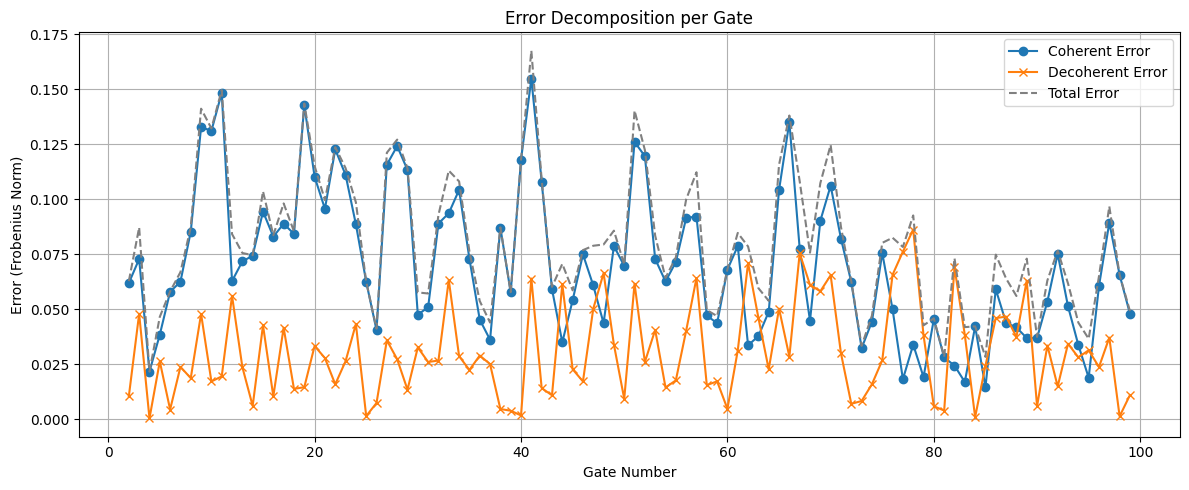

In [162]:
import matplotlib.pyplot as plt

x_axis = df["Gate Num"].values[1:]

plt.figure(figsize=(12, 5))
plt.plot(x_axis, coh_error_list, label='Coherent Error', marker='o')
plt.plot(x_axis, decoh_error_list, label='Decoherent Error', marker='x')
plt.plot(x_axis, total_error_list, label='Total Error', linestyle='--', color='gray')
plt.xlabel("Gate Number")
plt.ylabel("Error (Frobenius Norm)")
plt.title("Error Decomposition per Gate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250428\H10M22S46\q4_TomoGateErrorTest_20250428102913_TomoGateError.csv"
df = pd.read_csv(file_path)



# === Step 1: 將 (X, Y, Z) → [-1, 1] → 投影到球面 → 重建 rho ===
def expectation_from_prob(p):
    return 2 * p - 1

X_exp = expectation_from_prob(df["X Data"].values)
Y_exp = expectation_from_prob(df["Y Data"].values)
Z_exp = expectation_from_prob(df["Z Data"].values)

# 正規化至球面
bloch_vectors = []
for x, y, z in zip(X_exp, Y_exp, Z_exp):
    r = np.array([x, y, z])
    norm = np.linalg.norm(r)
    if norm > 1e-8:
        r_proj = r / norm
    else:
        r_proj = np.array([0.0, 0.0, 1.0])  # 預設純態
    bloch_vectors.append(r_proj)

# 轉換為密度矩陣
def build_density_matrix(x, y, z):
    I = np.eye(2)
    return 0.5 * (I + x * sigma_x + y * sigma_y + z * sigma_z)

density_matrices = [build_density_matrix(*r) for r in bloch_vectors]

# === Step 2: 分析 Hamiltonian 與 Coherence/Decoherence ===
hx_list, hy_list, hz_list = [], [], []
coh_error_list, decoh_error_list, total_error_list = [], [], []

for n in range(len(density_matrices) - 1):
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]

    # 理想演化
    rotated = sigma_x @ rho_n @ sigma_x

    delta_rho = rho_np1 - rotated

    # RHS 向量 v_k = Tr(Δρ ⋅ σ_k)
    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 建立係數矩陣 M[k, j] = Tr(-i [σ_j, ρ_n] ⋅ σ_k)
    M = np.zeros((3, 3))
    for k, sigma_k in enumerate(paulis):
        for j, sigma_j in enumerate(paulis):
            comm = sigma_j @ rho_n - rho_n @ sigma_j
            M[k, j] = np.trace(-1j * comm @ sigma_k).real

    try:
        h_vector, *_ = np.linalg.lstsq(M, v, rcond=None)
    except Exception:
        h_vector = np.array([np.nan, np.nan, np.nan])

    hx, hy, hz = h_vector
    hx_list.append(hx)
    hy_list.append(hy)
    hz_list.append(hz)

    h = hx * sigma_x + hy * sigma_y + hz * sigma_z
    delta_rho_coh = -1j * (h @ rho_n - rho_n @ h)
    delta_rho_decoh = delta_rho - delta_rho_coh

    coh_error = np.linalg.norm(delta_rho_coh, ord='fro')
    decoh_error = np.linalg.norm(delta_rho_decoh, ord='fro')
    total_error = np.linalg.norm(delta_rho, ord='fro')

    coh_error_list.append(coh_error)
    decoh_error_list.append(decoh_error)
    total_error_list.append(total_error)


In [293]:

import numpy as np

# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

# 初始態為 |0⟩
rho_0 = np.array([[1, 0],
                  [0, 0]])

# 建立旋轉矩陣：U(θ) = exp(-i θ/2 σ_x)
def rotation_x(theta):
    return np.cos(theta / 2) * np.eye(2) - 1j * np.sin(theta / 2) * sigma_x
def rotation_y(theta):
    return np.cos(theta / 2) * np.eye(2) - 1j * np.sin(theta / 2) * sigma_y
def rotation_z(theta):
    return np.cos(theta / 2) * np.eye(2) - 1j * np.sin(theta / 2) * sigma_z
# 生成密度矩陣列表
num_points = 99
angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)
density_matrices = []

for theta in angles:
    U = rotation_y(theta)
    rho = U @ rho_0 @ U.conj().T
    density_matrices.append(rho)

hx_list, hy_list, hz_list = [], [], []
coh_error_list, decoh_error_list, total_error_list = [], [], []

for n in range(len(density_matrices) - 1):
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]

    # 理想演化
    rotated = rho_n

    delta_rho = rho_np1 - rotated

    # Bloch vector r_k = Tr(ρ_n ⋅ σ_k)
    r = np.array([np.trace(rho_n @ sigma_k).real for sigma_k in paulis])

    # RHS 向量 v_k = Tr(Δρ ⋅ σ_k)
    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 嘗試透過 v = h × r 解出 h
    r_norm_squared = np.dot(r, r)
    if r_norm_squared > 1e-8:
        h_vector =  1/2 * np.cross(r, v) / r_norm_squared
    else:
        h_vector = np.array([np.nan, np.nan, np.nan])

    # 存儲結果
    hx_list.append(h_vector[0])
    hy_list.append(h_vector[1])
    hz_list.append(h_vector[2])

    # 錯誤分析（選填）
    coh_error = np.linalg.norm(np.cross(h_vector, r))
    decoh_error = np.linalg.norm(1/2*v - np.cross(h_vector, r))
    total_error = np.linalg.norm(1/2*v)

    coh_error_list.append(coh_error)
    decoh_error_list.append(decoh_error)
    total_error_list.append(total_error)
bloch_vectors = []

for rho in density_matrices:
    r = np.array([np.trace(rho @ sigma_k).real for sigma_k in paulis])
    bloch_vectors.append(r)

# with XX gates flip


generate some Hamiltonian distribution to simulate density matrices' change.

In [24]:
import numpy as np
from scipy.linalg import expm

# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

# 參數設定
N = 1000  # 你想要幾個時間點
delta_t = 1.0  # 每一小段的時間長度
h_strength = 0.05  # 控制隨機 H 的幅度

# 初始態 |0⟩
rho_0 = np.array([[1, 0],
                  [0, 0]])
ket_plus = np.array([[1], [1]]) / np.sqrt(2)
rho_plus = ket_plus @ ket_plus.conj().T

# |+i> = (|0> + i|1>) / sqrt(2)
ket_plus_i = np.array([[1], [1j]]) / np.sqrt(2)
rho_plus_i = ket_plus_i @ ket_plus_i.conj().T
# 儲存結果
hx_list, hy_list, hz_list = [], [], []
density_matrices = [rho_0]
bloch_vectors = []

# 隨機產生 h 向量（方向隨機，長度為 h_strength）
np.random.seed(42)  # 可重現性
h_vectors = h_strength * np.random.randn(N,3)
hx_strength = 0.01
hy_strength = 0.01
hz_strength = 1

# 時間步進模擬
for h in h_vectors:
    hx, hy, hz = h
    hx_list.append(hx*hx_strength)
    hy_list.append(hy*hy_strength)
    hz_list.append(hz*hz_strength)

    H = hx * hx_strength * sigma_x + hy * hy_strength *  sigma_y + hz * hz_strength * sigma_z
    U = expm(-1j * delta_t * H)
    
    rho_prev = density_matrices[-1]
    rho_next = U @ sigma_x @ rho_prev @ sigma_x @ U.conj().T 
    density_matrices.append(rho_next)

# 移除多餘最後一個以外
density_matrices = density_matrices[:-1]

# Bloch vectors 對應
for rho in density_matrices:
    r = np.array([np.trace(rho @ sigma_k).real for sigma_k in paulis])
    bloch_vectors.append(r)


Using the simulation density matrices to calculate hamiltonian distribution.

In [20]:
hx_list, hy_list, hz_list = [], [], []
coh_error_list, decoh_error_list, total_error_list = [], [], []

for n in range(len(density_matrices) - 1):
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]

    # 理想演化
    rotated = sigma_x @ rho_n @ sigma_x

    delta_rho = rho_np1 - rotated

    # Bloch vector r_k = Tr(ρ_n ⋅ σ_k)
    r = np.array([np.trace(rho_n @ sigma_k).real for sigma_k in paulis])

    # RHS 向量 v_k = Tr(Δρ ⋅ σ_k)
    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 嘗試透過 v = h × r 解出 h
    r_norm_squared = np.dot(r, r)
    if r_norm_squared > 1e-8:
        h_vector =  1/2 * np.cross(r, v) / r_norm_squared
    else:
        h_vector = np.array([np.nan, np.nan, np.nan])

    # 存儲結果
    hx_list.append(h_vector[0])
    hy_list.append(h_vector[1])
    hz_list.append(h_vector[2])

    # 錯誤分析（選填）
    coh_error = np.linalg.norm(np.cross(h_vector, r))
    decoh_error = np.linalg.norm(1/2*v - np.cross(h_vector, r))
    total_error = np.linalg.norm(1/2*v)

    coh_error_list.append(coh_error)
    decoh_error_list.append(decoh_error)
    total_error_list.append(total_error)


let raw data convert to density matrices, and calculate hamiltonian distribution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

# file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250428\H10M22S46\q4_TomoGateErrorTest_20250428102913_TomoGateError.csv"
# file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250421\H13M54S24\q2_TomoGateErrorTest_20250421140455_TomoGateError.csv"
file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\tomo\q2\q2_TomoGateErrorTest_20250708153303_TomoGateError.csv"
df = pd.read_csv(file_path)



# === Step 1: 將 (X, Y, Z) → [-1, 1] → 投影到球面 → 重建 rho ===
def expectation_from_prob(p):
    return 2 * p - 1

X_exp = expectation_from_prob(df["X Data"].values)
Y_exp = expectation_from_prob(df["Y Data"].values)
Z_exp = expectation_from_prob(df["Z Data"].values)

# 正規化至球面
bloch_vectors = []
for x, y, z in zip(X_exp, Y_exp, Z_exp):
    r = np.array([x, y, z])
    norm = np.linalg.norm(r)
    if norm > 1e-8:
        r_proj = r / norm
    else:
        r_proj = np.array([0.0, 0.0, 1.0])  # 預設純態
    bloch_vectors.append(r_proj)

# 轉換為密度矩陣
def build_density_matrix(x, y, z):
    I = np.eye(2)
    return 0.5 * (I + x * sigma_x + y * sigma_y + z * sigma_z)

density_matrices = [build_density_matrix(*r) for r in bloch_vectors]

hx_list, hy_list, hz_list = [], [], []
coh_error_list, decoh_error_list, total_error_list = [], [], []

for n in range(len(density_matrices) - 1):
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]

    # 理想演化
    rotated = sigma_x @ rho_n @ sigma_x

    delta_rho = rho_np1 - rotated

    # Bloch vector r_k = Tr(ρ_n ⋅ σ_k)
    r = np.array([np.trace(rho_n @ sigma_k).real for sigma_k in paulis])
    ro = np.array([np.trace(rotated @ sigma_k).real for sigma_k in paulis])
    # RHS 向量 v_k = Tr(Δρ ⋅ σ_k)
    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 嘗試透過 v = h × r 解出 h
    r_norm_squared = np.dot(r, r)
    if r_norm_squared > 1e-8:
        h_vector =  1/2 * np.cross(r, v) / r_norm_squared
    else:
        h_vector = np.array([np.nan, np.nan, np.nan])

    # 存儲結果
    hx_list.append(h_vector[0])
    hy_list.append(h_vector[1])
    hz_list.append(h_vector[2])

    # 錯誤分析（選填）
    coh_error = np.linalg.norm(2 * np.cross(h_vector, r))
    decoh_error = np.linalg.norm(v - 2 * np.cross(h_vector, r))
    total_error = np.linalg.norm(v)

    coh_error_list.append(coh_error)
    decoh_error_list.append(decoh_error)
    total_error_list.append(total_error)
    if n == 0:
        print(f"rho_vector = {r}")
        print(f"delta_vector = {v}")
        print(f"h_vector = {h_vector}")

rho_vector = [ 0.20355802 -0.08481584  0.97538218]
delta_vector = [-0.28920706 -0.07129231 -0.0208514 ]
h_vector = [ 0.03565289 -0.13892147 -0.01952073]


draw hamiltonian distribution

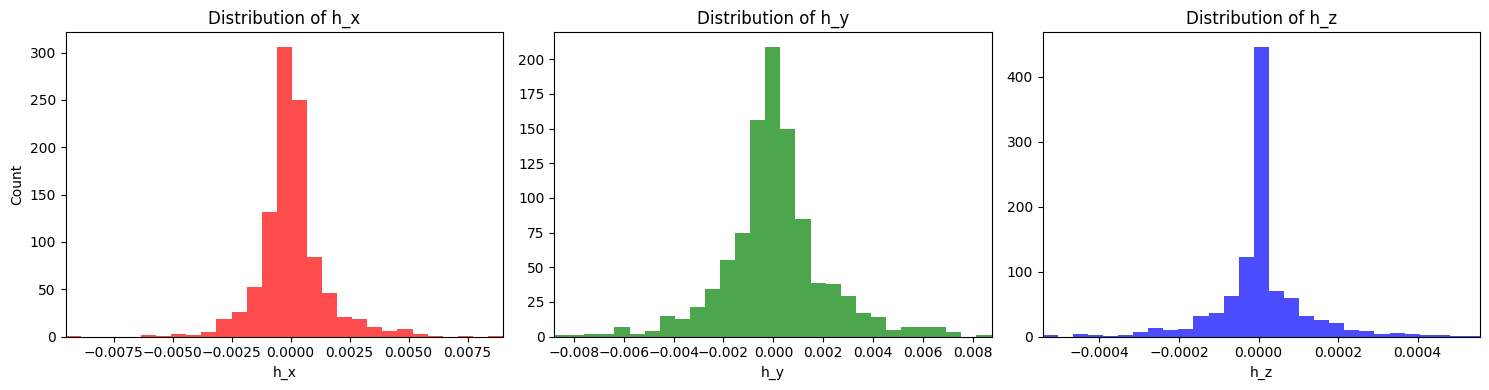

x_mean = 3.349111817653369e-05
y_mean = 6.359641984033221e-05
z_mean = 1.8726082621661832e-06
x_std = 0.0014255161638287556
y_std = 0.0020686478439773314
z_std = 0.0001131472140091754


In [21]:
%matplotlib inline
# 改為畫出直方圖（histogram）
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# 移除 nan 值
hx_clean = [h for h in hx_list if not np.isnan(h)]
hy_clean = [h for h in hy_list if not np.isnan(h)]
hz_clean = [h for h in hz_list if not np.isnan(h)]

# 自動計算範圍
hx_min, hx_max = min(hx_clean), max(hx_clean)
hy_min, hy_max = min(hy_clean), max(hy_clean)
hz_min, hz_max = min(hz_clean), max(hz_clean)

# 依據範圍自動切 bins（你也可以設固定數量，如 bins=50）
hx_bins = np.linspace(hx_min, hx_max, 30)
hy_bins = np.linspace(hy_min, hy_max, 30)
hz_bins = np.linspace(hz_min, hz_max, 30)

# 畫 histogram
ax[0].hist(hx_clean, bins=hx_bins, color='r', alpha=0.7)
ax[0].set_xlabel("h_x")
ax[0].set_ylabel("Count")
ax[0].set_title("Distribution of h_x")
ax[0].set_xlim(hx_min, hx_max)

ax[1].hist(hy_clean, bins=hy_bins, color='g', alpha=0.7)
ax[1].set_xlabel("h_y")
ax[1].set_title("Distribution of h_y")
ax[1].set_xlim(hy_min, hy_max)

ax[2].hist(hz_clean, bins=hz_bins, color='b', alpha=0.7)
ax[2].set_xlabel("h_z")
ax[2].set_title("Distribution of h_z")
ax[2].set_xlim(hz_min, hz_max)

plt.tight_layout()
plt.show()
print(f"x_mean = {np.mean(hx_clean)}")
print(f"y_mean = {np.mean(hy_clean)}")
print(f"z_mean = {np.mean(hz_clean)}")
print(f"x_std = {np.std(hx_clean)}")
print(f"y_std = {np.std(hy_clean)}")
print(f"z_std = {np.std(hz_clean)}")

some calculate checking (not important)

In [56]:
h = hx_list[1]*sigma_x + hy_list[1]*sigma_y + hz_list[1]*sigma_z 

delta = -1j* (h @ density_matrices[1] - density_matrices[1] @ h)
delta_vector = np.array([np.trace(delta @ sigma_k).real for sigma_k in paulis])
print(delta_vector)

delta2 = density_matrices[2] - sigma_x @ density_matrices[1] @ sigma_x
delta_vector2 = np.array([np.trace(delta2 @ sigma_k).real for sigma_k in paulis])
print(delta_vector2)

h_vector_0 = np.array([np.trace(h @ sigma_k).real for sigma_k in paulis])
r_0 = np.array([np.trace(density_matrices[1] @ sigma_k).real for sigma_k in paulis])
print(np.cross(h_vector_0, r_0))

print(np.cross(r_0,delta_vector2))
print(h_vector_0)

np.dot(delta_vector2,r_0)


[ 0.28716408 -0.18151966 -0.02715238]
[ 0.28638826 -0.18139716 -0.03617646]
[ 0.28716408 -0.18151966 -0.02715238]
[-0.18120317 -0.28840808  0.01166351]
[-0.18120317 -0.28840808  0.01166351]


0.00905819011701318

coherence error and fitting error par gates (need to change x_axis when you want to check simulation result)

In [5]:
import matplotlib.pyplot as plt
%matplotlib qt5
x_axis = df["Gate Num"].values[1:]
plt.figure(figsize=(12, 5))
plt.plot(x_axis, coh_error_list, label='Coherent Error', marker='o')
plt.plot(x_axis, decoh_error_list, label='fitting Error', marker='x')
plt.plot(x_axis, total_error_list, label='Total Error', linestyle='--', color='gray')
plt.xlabel("Gate Number")
plt.ylabel("Error (Frobenius Norm)")
plt.title("Error Decomposition per Gate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


also not important checking

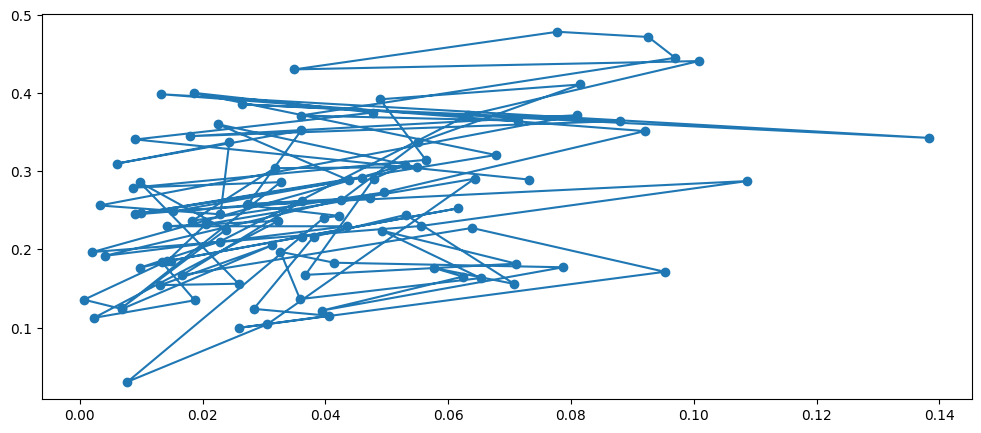

In [58]:
plt.figure(figsize=(12, 5))
plt.plot(decoh_error_list, coh_error_list, label='Coherent Error', marker='o')
plt.show()


check the hamiltonian and some important vector in bloch sphere.

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib qt5
# 選擇某一筆資料進行可視化（例如第 n = 0 筆）
n_vis =17

rho_n = density_matrices[n_vis]
rho_np1 = density_matrices[n_vis + 1]
rotated = sigma_x @ rho_n @ sigma_x
delta_rho = rho_np1 - rotated

# Bloch vectors
r = np.array([np.trace(rotated @ sigma_k).real for sigma_k in paulis])
v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])
r_1 = np.array([np.trace(rho_np1 @ sigma_k).real for sigma_k in paulis])
r_norm_sq = np.dot(r, r)
if r_norm_sq > 1e-8:
    h = 1/2 * np.cross(r, v) / r_norm_sq
else:
    h = np.array([0, 0, 0])

# ========== Plotting ==========
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title("Visualization of Bloch Vectors: r, v = h × r, and h")

# Draw Bloch sphere
u, v_sphere = np.mgrid[0:2*np.pi:100j, 0:np.pi:100j]
x_sphere = np.cos(u) * np.sin(v_sphere)
y_sphere = np.sin(u) * np.sin(v_sphere)
z_sphere = np.cos(v_sphere)
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.1, linewidth=0)

# Origin
origin = np.zeros(3)

# Plot vectors
ax.quiver(*origin, *r, color='green', label=f'r_{n_vis}_rotated', linewidth=2)
ax.quiver(*origin, *v, color='red', label='v = Δr', linewidth=2)
ax.quiver(*origin, *h, color='blue', label='h (Hamiltonian vector)', linewidth=2)
ax.quiver(*origin, *r_1, color='yellow', label=f'r_{n_vis+1}',linewidth=2)
# Cross check vector identity (optional)
v_cross_check = 2 * np.cross(h, r)
ax.quiver(*origin, *v_cross_check, color='orange', linestyle='dashed', linewidth=1, label='h × r (check)')

# Axis limits
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])

# Labels
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# Legend
ax.legend()
plt.tight_layout()
plt.show()
print(np.linalg.norm(h))
print(np.linalg.norm(v))

0.1701360025931077
0.3454647570713744


density metrices in bloch sphere

In [60]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
%matplotlib qt5
# 擷取 bloch_vectors 的 x, y, z 元素

bloch_array = np.array(bloch_vectors)
x_vals, y_vals, z_vals = bloch_array[:, 0], bloch_array[:, 1], bloch_array[:, 2]

# 建立 Bloch 球
u, v = np.mgrid[0:2*np.pi:100j, 0:np.pi:100j]
x_sphere = np.cos(u) * np.sin(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(v)

# Plotting
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title("Distribution of Bloch Vectors from Density Matrices")

# 畫出 Bloch 球
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.1, linewidth=0)

# 畫出 Bloch 向量分布
ax.scatter(x_vals, y_vals, z_vals, color='red', s=20, label='Bloch vectors')

# 設定視圖範圍與標籤
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.tight_layout()
plt.show()


animation of evoluton

In [70]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import animation
import numpy as np
%matplotlib qt5
# 建立 Bloch 球
u, v = np.mgrid[0:2*np.pi:60j, 0:np.pi:30j]
x_sphere = np.cos(u) * np.sin(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(v)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.05, linewidth=0)

ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Bloch Vector Animation with Hamiltonian')

origin = np.zeros(3)

# 初始化為空（會在 update 中填入）
r_quiver = None
v_quiver = None
h_quiver = None
r_1_quiver = None

def update(n):
    global r_quiver, v_quiver, h_quiver, r_1_quiver

    # 移除前一個向量
    if r_quiver: r_quiver.remove()
    if v_quiver: v_quiver.remove()
    if h_quiver: h_quiver.remove()
    if r_1_quiver: r_1_quiver.remove()
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]
    rotated = sigma_x @ rho_n @ sigma_x
    delta_rho = rho_np1 - rotated
    r_1 = np.array([np.trace(rho_np1 @ sigma_k).real for sigma_k in paulis])
    r = np.array([np.trace(rho_n @ sigma_k).real for sigma_k in paulis])
    v_vec_arr = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    r_norm_sq = np.dot(r, r)
    h = 1/2*np.cross(r, v_vec_arr) / r_norm_sq if r_norm_sq > 1e-8 else np.zeros(3)

    # 畫新的向量
    r_1_quiver = ax.quiver(*origin, *r_1, color='yellow', linewidth=2)
    r_quiver = ax.quiver(*origin, *r, color='green', linewidth=2)
    v_quiver = ax.quiver(*origin, *v_vec_arr, color='red', linewidth=2)
    h_quiver = ax.quiver(*origin, *h, color='blue', linewidth=2)

    ax.set_title(f"Step {n} / {len(density_matrices)-2}")
    return r_quiver, v_quiver, h_quiver, r_1_quiver

ani = animation.FuncAnimation(fig, update, frames=len(density_matrices)-1, interval=500, blit=False)

# 如果你在非互動式環境，改用儲存
# ani.save("bloch_animation.mp4", writer="ffmpeg", fps=2)

plt.show()


## without xx gate flip


In [62]:
import numpy as np
from scipy.linalg import expm

# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

# 參數設定
N = 99  # 你想要幾個時間點
delta_t = 1.0  # 每一小段的時間長度
h_strength = 1  # 控制隨機 H 的幅度

# 初始態 |0⟩
rho_0 = np.array([[1, 0],
                  [0, 0]])

# 儲存結果
hx_list, hy_list, hz_list = [], [], []
density_matrices = [rho_0]
bloch_vectors = []

# 隨機產生 h 向量（方向隨機，長度為 h_strength）
# np.random.seed(42) 
np.random  # 可重現性
h_vectors = h_strength * np.random.randn(N,3)

# 時間步進模擬
for h in h_vectors:
    hx, hy, hz = h
    drift_amp = 0
    drift_angle = 0/360*np.pi*2
    drift_x = drift_amp*np.cos(drift_angle)
    drift_y = drift_amp*np.sin(drift_angle)
    hx_list.append(hx*0.07416751102773608+drift_x+0.02222095157769819)
    hy_list.append(hy*0.034498442525437156+drift_y-0.0008021855919747018)
    hz_list.append(hz*0.0560110020928766+0.0007401998962057134)

    H = (hx*0.07416751102773608+drift_x+0.02222095157769819) * sigma_x + (hy*0.034498442525437156+drift_y-0.0008021855919747018) *  sigma_y + (hz*0.0560110020928766+0.0007401998962057134) * sigma_z
    U = expm(-1j * delta_t * H)
    
    rho_prev = density_matrices[-1]
    rho_next = U @ rho_prev @ U.conj().T 
    density_matrices.append(rho_next)

# 移除多餘最後一個以外
density_matrices = density_matrices[:-1]

# Bloch vectors 對應
for rho in density_matrices:
    r = np.array([np.trace(rho @ sigma_k).real for sigma_k in paulis])
    bloch_vectors.append(r)


In [63]:
hx_list, hy_list, hz_list = [], [], []
coh_error_list, decoh_error_list, total_error_list = [], [], []

for n in range(len(density_matrices) - 1):
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]

    # 理想演化
    rotated =  rho_n 

    delta_rho = rho_np1 - rotated

    # Bloch vector r_k = Tr(ρ_n ⋅ σ_k)
    r = np.array([np.trace(rho_n @ sigma_k).real for sigma_k in paulis])

    # RHS 向量 v_k = Tr(Δρ ⋅ σ_k)
    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 嘗試透過 v = h × r 解出 h
    r_norm_squared = np.dot(r, r)
    if r_norm_squared > 1e-8:
        h_vector =  1/2 * np.cross(r, v) / r_norm_squared
    else:
        h_vector = np.array([np.nan, np.nan, np.nan])

    # 存儲結果
    hx_list.append(h_vector[0])
    hy_list.append(h_vector[1])
    hz_list.append(h_vector[2])

    # 錯誤分析（選填）
    coh_error = np.linalg.norm(np.cross(h_vector, r))
    decoh_error = np.linalg.norm(1/2*v - np.cross(h_vector, r))
    total_error = np.linalg.norm(1/2*v)

    coh_error_list.append(coh_error)
    decoh_error_list.append(decoh_error)
    total_error_list.append(total_error)


In [64]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250428\H10M22S46\q4_TomoGateErrorTest_20250428102913_TomoGateError.csv"
# file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250421\H13M54S24\q2_TomoGateErrorTest_20250421140455_TomoGateError.csv"
file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\tomo\q2\500_q2_TomoGateErrorTest_20250708165653_TomoGateError.csv"
df = pd.read_csv(file_path)



# === Step 1: 將 (X, Y, Z) → [-1, 1] → 投影到球面 → 重建 rho ===
def expectation_from_prob(p):
    return 2 * p - 1

X_exp = expectation_from_prob(df["X Data"].values)
Y_exp = expectation_from_prob(df["Y Data"].values)
Z_exp = expectation_from_prob(df["Z Data"].values)

# 正規化至球面
bloch_vectors = []
for x, y, z in zip(X_exp, Y_exp, Z_exp):
    r = np.array([x, y, z])
    norm = np.linalg.norm(r)
    if norm > 1e-8:
        r_proj = r / norm
    else:
        r_proj = np.array([0.0, 0.0, 1.0])  # 預設純態
    bloch_vectors.append(r_proj)

# 轉換為密度矩陣
def build_density_matrix(x, y, z):
    I = np.eye(2)
    return 0.5 * (I + x * sigma_x + y * sigma_y + z * sigma_z)

density_matrices = [build_density_matrix(*r) for r in bloch_vectors]

hx_list, hy_list, hz_list = [], [], []
coh_error_list, decoh_error_list, total_error_list = [], [], []

for n in range(1,len(density_matrices) - 2):
    rho_n = density_matrices[n]
    rho_np2 = density_matrices[n + 2]

    # 理想演化
    rotated = rho_n

    delta_rho = rho_np2 - rotated

    # Bloch vector r_k = Tr(ρ_n ⋅ σ_k)
    r = np.array([np.trace(rho_n @ sigma_k).real for sigma_k in paulis])
    ro = np.array([np.trace(rotated @ sigma_k).real for sigma_k in paulis])
    # RHS 向量 v_k = Tr(Δρ ⋅ σ_k)
    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 嘗試透過 v = h × r 解出 h
    r_norm_squared = np.dot(r, r)
    if r_norm_squared > 1e-8:
        h_vector =  1/2 * np.cross(r, v) / r_norm_squared
    else:
        h_vector = np.array([np.nan, np.nan, np.nan])

    # 存儲結果
    hx_list.append(h_vector[0])
    hy_list.append(h_vector[1])
    hz_list.append(h_vector[2])

    # 錯誤分析（選填）
    coh_error = np.linalg.norm(2 * np.cross(h_vector, r))
    decoh_error = np.linalg.norm(v - 2 * np.cross(h_vector, r))
    total_error = np.linalg.norm(v)

    coh_error_list.append(coh_error)
    decoh_error_list.append(decoh_error)
    total_error_list.append(total_error)


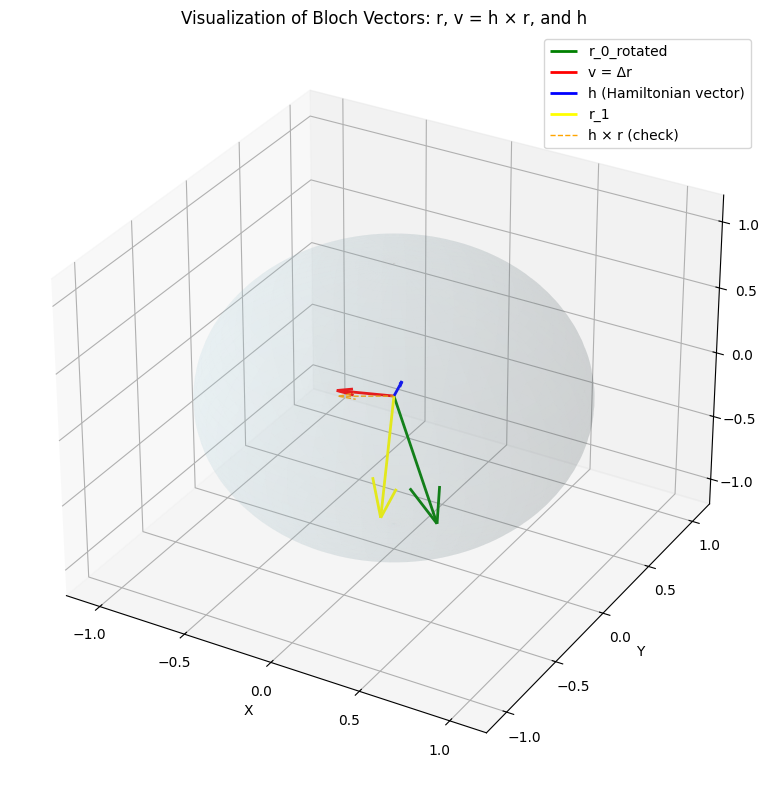

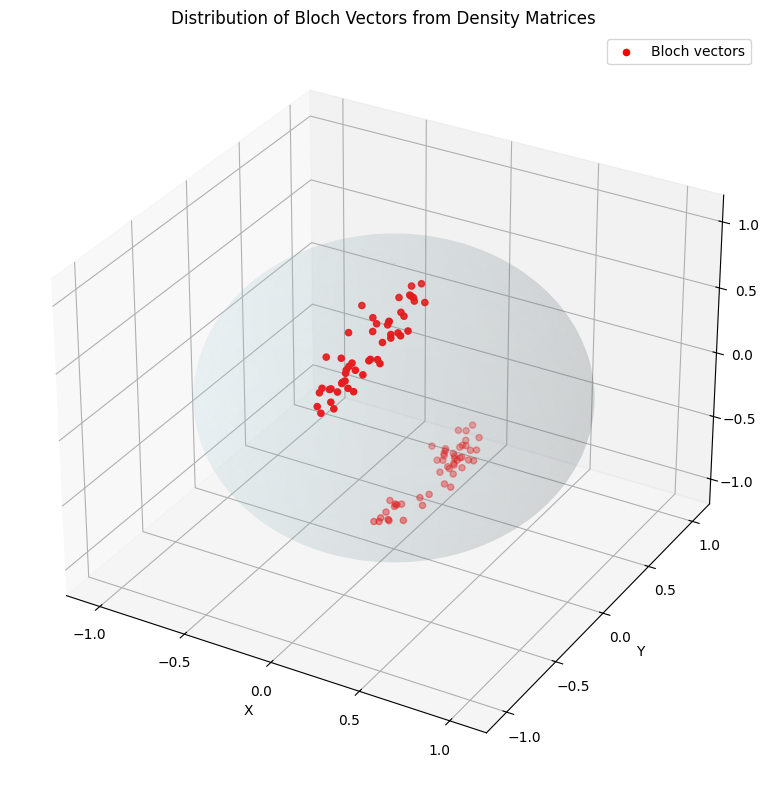

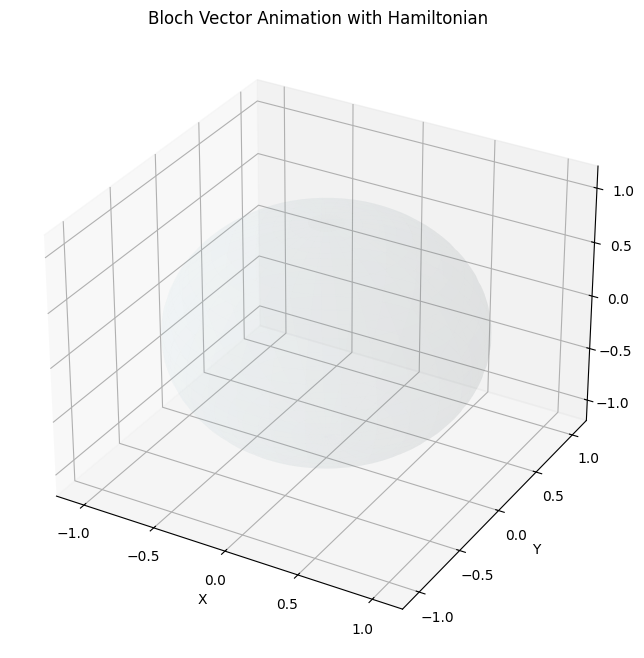

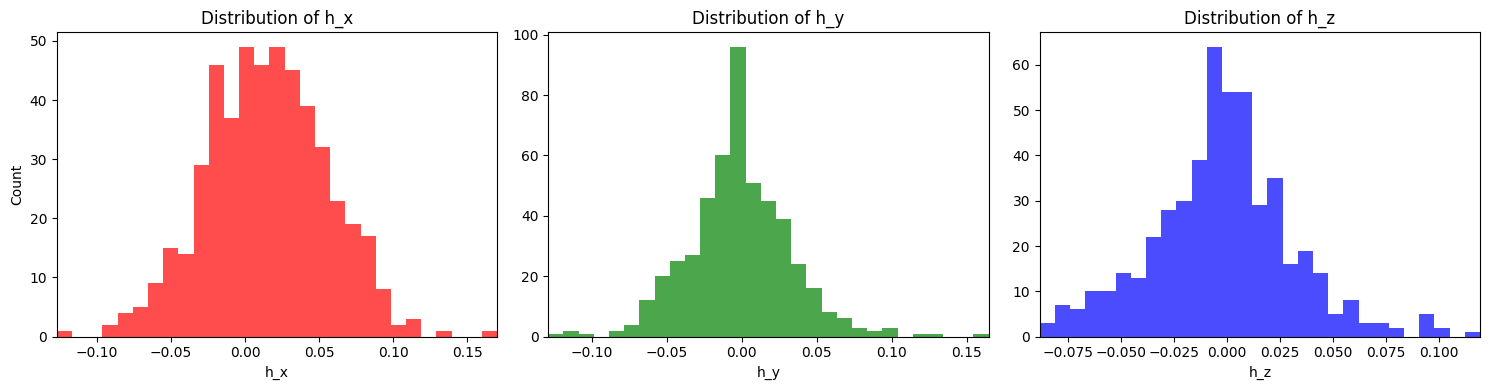

x_mean = 0.014784296120167972
y_mean = -0.0014346181767297566
z_mean = -0.0020560254404819373
x_std = 0.040930654633508194
y_std = 0.03432581037650913
z_std = 0.032998416586247636


In [65]:
%matplotlib inline
# 改為畫出直方圖（histogram）
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# 移除 nan 值
hx_clean = [h for h in hx_list if not np.isnan(h)]
hy_clean = [h for h in hy_list if not np.isnan(h)]
hz_clean = [h for h in hz_list if not np.isnan(h)]

# 自動計算範圍
hx_min, hx_max = min(hx_clean), max(hx_clean)
hy_min, hy_max = min(hy_clean), max(hy_clean)
hz_min, hz_max = min(hz_clean), max(hz_clean)

# 依據範圍自動切 bins（你也可以設固定數量，如 bins=50）
hx_bins = np.linspace(hx_min, hx_max, 30)
hy_bins = np.linspace(hy_min, hy_max, 30)
hz_bins = np.linspace(hz_min, hz_max, 30)

# 畫 histogram
ax[0].hist(hx_clean, bins=hx_bins, color='r', alpha=0.7)
ax[0].set_xlabel("h_x")
ax[0].set_ylabel("Count")
ax[0].set_title("Distribution of h_x")
ax[0].set_xlim(hx_min, hx_max)

ax[1].hist(hy_clean, bins=hy_bins, color='g', alpha=0.7)
ax[1].set_xlabel("h_y")
ax[1].set_title("Distribution of h_y")
ax[1].set_xlim(hy_min, hy_max)

ax[2].hist(hz_clean, bins=hz_bins, color='b', alpha=0.7)
ax[2].set_xlabel("h_z")
ax[2].set_title("Distribution of h_z")
ax[2].set_xlim(hz_min, hz_max)

plt.tight_layout()
plt.show()
print(f"x_mean = {np.mean(hx_clean)}")
print(f"y_mean = {np.mean(hy_clean)}")
print(f"z_mean = {np.mean(hz_clean)}")
print(f"x_std = {np.std(hx_clean)}")
print(f"y_std = {np.std(hy_clean)}")
print(f"z_std = {np.std(hz_clean)}")

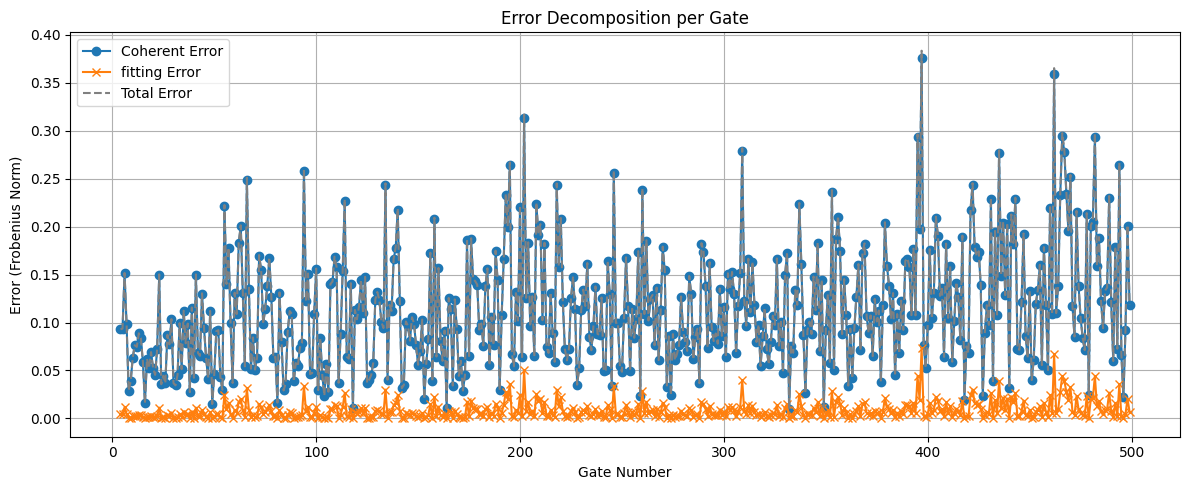

In [66]:
import matplotlib.pyplot as plt
%matplotlib inline
x_axis = df["Gate Num"].values[3:]
# x_axis = range(97)
plt.figure(figsize=(12, 5))
plt.plot(x_axis, coh_error_list, label='Coherent Error', marker='o')
plt.plot(x_axis, decoh_error_list, label='fitting Error', marker='x')
plt.plot(x_axis, total_error_list, label='Total Error', linestyle='--', color='gray')
plt.xlabel("Gate Number")
plt.ylabel("Error (Frobenius Norm)")
plt.title("Error Decomposition per Gate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [72]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
%matplotlib qt5
# 擷取 bloch_vectors 的 x, y, z 元素

bloch_array = np.array(bloch_vectors)
x_vals, y_vals, z_vals = bloch_array[:, 0], bloch_array[:, 1], bloch_array[:, 2]

# 建立 Bloch 球
u, v = np.mgrid[0:2*np.pi:100j, 0:np.pi:100j]
x_sphere = np.cos(u) * np.sin(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(v)

# Plotting
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title("Distribution of Bloch Vectors from Density Matrices")

# 畫出 Bloch 球
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.1, linewidth=0)

# 畫出 Bloch 向量分布
ax.scatter(x_vals, y_vals, z_vals, color='red', s=20, label='Bloch vectors')

# 設定視圖範圍與標籤
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.tight_layout()
plt.show()


In [68]:
import numpy as np

A = np.array([[1, 3], [2, 6]])
A_pinv = np.linalg.pinv(A)

print("A^+ =", A_pinv)


A^+ = [[0.02 0.04]
 [0.06 0.12]]
